# JaxPM — Evaluación de corridas experimentales


In [7]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import pickle
import numpy as np
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import haiku as hk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from jax.experimental.ode import odeint

# Módulos del proyecto — ajusta sys.path si es necesario
import sys
sys.path.insert(0, "/cosmos_storage/home/diegovillalba/JaxPM/")

from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk
from jaxpm.pm import make_ode_fn, get_delta

# Para reconstruir los modelos
from jaxpm.nn import CNN, NeuralSplineFourierFilter

jax.config.update("jax_enable_x64", False)
print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


In [ ]:

from pathlib import Path
import glob

MODELS_DIR = Path("/cosmos_storage/home/diegovillalba/JaxPM/models")

RUNS = {
    "LR (baseline)": None,
    "cnn electric-dream"           : MODELS_DIR / "electric-dream-78/best_*.pkl",
    "cnn_wst efficient-thunder-86" : MODELS_DIR / "efficient-thunder-86/best_0.000_weights*.pkl",
    "cnn_wst pious-wildflower-89"  : MODELS_DIR / "pious-wildflower-89/best_0.000_weights.pkl",
    "cnn_wst azure-salad-88"       : MODELS_DIR / "azure-salad-88/best_0.000_weights.pkl",
    "cnn_wst iconc-forest-90"      : MODELS_DIR / "iconic-forest-90/best_0.000_weights.pkl",
}

print(f"{'Run':<35} {'Status':<10} {'File'}")
print("─" * 90)
all_ok = True
for name, path in RUNS.items():
    if path is None:
        print(f"{name:<35} {'✓ skip':<10} (no model)")
        continue

    matches = sorted(path.parent.glob(path.name))

    if matches:
        print(f"{name:<35} {'✓ found':<10} {matches[-1].name}")
    else:
        print(f"{name:<35} {'✗ MISSING':<10} {path}")
        all_ok = False

print("─" * 90)
print("All files found ✓" if all_ok else "Some files MISSING ✗ — check paths above")


Run                                 Status     File
──────────────────────────────────────────────────────────────────────────────────────────
LR (baseline)                       ✓ skip     (no model)
cnn electric-dream                  ✓ found    best_0.000_weights.pkl
cnn_wst efficient-thunder-86        ✓ found    best_0.000_weights.pkl
cnn_wst pious-wildflower-89         ✓ found    best_0.000_weights.pkl
cnn_wst azure-salad-88              ✓ found    best_0.000_weights.pkl
cnn_wst iconc-forest-90             ✗ MISSING  /cosmos_storage/home/diegovillalba/JaxPM/models/iconc-forest-90/best_0.000_weights.pkl
──────────────────────────────────────────────────────────────────────────────────────────
Some files MISSING ✗ — check paths above


In [ ]:
/cosmos_storage/home/diegovillalba/JaxPM/models/pious-wildflower-89/best_0.000_weights.pkl

## 1. Rutas y configuración


In [3]:
# ── Ajusta estas rutas ──────────────────────────────────────────────
DATA_DIR   = Path("/cosmos_storage/home/diegovillalba/JaxPM/data/matched_128_256_L256.0_S50_Np128")
MODELS_DIR = Path("/cosmos_storage/home/diegovillalba/JaxPM/models")

MESH_LR   = 128
MESH_HR   = 256
BOX_SIZE  = 256.0  # Mpc/h
N_TEST    = 5      # número de sims de test a evaluar por corrida
TEST_SIM_IDS = list(range(90, 90 + N_TEST))  # IDs de las sims de test

COSMOLOGY = jc.Planck15(Omega_c=0.25, sigma8=0.8)

# ── Checkpoints a comparar ──────────────────────────────────────────
# Cada entrada: nombre_display -> ruta al .pkl de best weights
RUNS = {
    "LR (baseline)": None,   # sin modelo; se calcula directo de pos_lr
    "cnn electric-dream" : MODELS_DIR / "electric-dream-78/best_*.pkl",
    # "kcorr gallant-lion-73" : MODELS_DIR / "gallant-lion-73/best_*.pkl",
    # "cnn lemon-cloud-74" : MODELS_DIR / "lemon-cloud-74/best_*.pkl",
    # "cnn revived-grass-60" : MODELS_DIR / "revived-grass-60/best_*.pkl",
    # "kcorr royal-energy-58"        : MODELS_DIR / "royal-energy-58/best_*.pkl",
    # "cnn volcanic-plasma-59"     : MODELS_DIR / "volcanic-plasma-59/best_*.pkl",
    # "cnn young-field-77"       : MODELS_DIR / "young-field-77/best_*.pkl",
    # "cnn glorious-wood-80"     : MODELS_DIR / "glorious-wood-80/best_*.pkl",
    "cnn_wst efficient-thunder-86" : MODELS_DIR / "efficient-thunder-86/best_*.pkl",
    "cnn_wst pious-wildflower-89" : MODELS_DIR / "pious-wildflower-89/best_*.pkl",
    "cnn_wst azure-salad-88" : MODELS_DIR / "azure-salad-88/best_*.pkl",
    "cnn_wst iconc-forest-90" : MODELS_DIR / "iconc-forest-90/best_*.pkl",
    # "cnn+kcorr"  : MODELS_DIR / "<nombre_run>/best_*.pkl",
    # Agrega tu run WST aquí:
    # "cnn_wst <nombre-run>": MODELS_DIR / "<nombre-run>/best_*.pkl",
}

# Parámetros del modelo CNN (deben coincidir con el run)
CNN_CFG = dict(
    channels_hidden_dim=16,
    n_convolutions=3,
    n_fully_connected=2,
    input_dim=1,
    kernel_size=3,
    pad_periodic=True,
    embed_globals=False,
    n_globals_embedding=1,
    globals_embedding_dim=64,
    global_conditioning="add",
    use_attention_interpolation=False,
    add_particle_velocities=True,
)

KCORR_CFG = dict(n_knots=16, latent_size=64)

# Parámetros del modelo WST (deben coincidir con el run)
WST_CFG = dict(
    wst_J=3,
    wst_L=4,
    channels_hidden_dim=32,
    n_convolutions=3,
    n_fully_connected=2,
    kernel_size=3,
    pad_periodic=True,
    embed_globals=False,
    n_globals_embedding=1,
    globals_embedding_dim=64,
    global_conditioning="add",
    use_attention_interpolation=False,
    add_particle_velocities=True,
)

print("Configuración cargada.")

# ── Output folder setup ──────────────────────────────────────────────────
# results_wst/
#   metrics_per_sim_<ts>.csv        one row per (run, sim, snapshot)
#   metrics_aggregated_<ts>.csv     mean±std over sims per (run, snapshot)
#   k_bins_<ts>.npy                 k-vector shared by all P(k) rows
#   eval_results_<ts>.json          nested JSON (backward compat)
#   slabs/
#     {run_slug}_sim{sim_id}_snap{snap_idx:02d}.npy  (MESH_HR, MESH_HR) float32
#     HR_target_sim{sim_id}_snap{snap_idx:02d}.npy
#     metadata.json
from datetime import datetime
from pathlib import Path

RESULTS_DIR = Path("results_wst")
SLABS_DIR   = RESULTS_DIR / "slabs"
FIGS_DIR    = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SLABS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Results will be saved to: {RESULTS_DIR.resolve()}")
print(f"Timestamp: {EVAL_TIMESTAMP}")


Configuración cargada.
Results will be saved to: /cosmos_storage/home/diegovillalba/JaxPM/pm2nbody/notebooks/results_wst
Timestamp: 20260416_075727


## 2. Helpers: carga de datos y modelos


In [4]:
def load_sim(sim_id, mesh_lr=MESH_LR, mesh_hr=MESH_HR):
    """
    Archivos en disco: unidades físicas [0, 256) Mpc/h
    (generate_data.py: pos / mesh * L)
    Conversión única a mesh_lr units — igual que read_data.py
    """
    pos_lr = np.load(DATA_DIR / f"pos_m{mesh_lr}_s{sim_id}.npy")
    vel_lr = np.load(DATA_DIR / f"vel_m{mesh_lr}_s{sim_id}.npy")
    pos_hr = np.load(DATA_DIR / f"pos_m{mesh_hr}_s{sim_id}.npy")
    vel_hr = np.load(DATA_DIR / f"vel_m{mesh_hr}_s{sim_id}.npy")
    avals  = np.load(DATA_DIR / "scale_factors.npy")
    pos_lr = jnp.array(pos_lr / BOX_SIZE * mesh_lr, dtype=jnp.float32)
    vel_lr = jnp.array(vel_lr / BOX_SIZE * mesh_lr, dtype=jnp.float32)
    pos_hr = jnp.array(pos_hr / BOX_SIZE * mesh_lr, dtype=jnp.float32)  # HR en mesh_lr units
    vel_hr = jnp.array(vel_hr / BOX_SIZE * mesh_lr, dtype=jnp.float32)
    avals  = jnp.array(avals)
    return pos_lr, vel_lr, pos_hr, vel_hr, avals


def glob_best_pkl(run_path):
    p = Path(str(run_path))
    if '*' in str(p):
        candidates = sorted(p.parent.glob(p.name))
        assert len(candidates) > 0, f"No pkl found: {p}"
        return candidates[-1]
    return p


def load_params(pkl_path):
    with open(glob_best_pkl(pkl_path), "rb") as f:
        return pickle.load(f)


def build_cnn_model():
    def CNNCorr(x, positions, scale_factors, velocities):
        return CNN(**CNN_CFG)(x=x, positions=positions,
                              global_features=scale_factors,
                              velocities=velocities)
    return hk.without_apply_rng(hk.transform(CNNCorr))


def build_kcorr_model():
    def KCorr(x, scale_factors):
        return NeuralSplineFourierFilter(**KCORR_CFG)(x, scale_factors)
    return hk.without_apply_rng(hk.transform(KCorr))


def infer_model_type(run_name):
    if run_name == "LR (baseline)":
        return None
    if "kcorr" in run_name and "cnn" not in run_name:
        return "kcorr"
    if "cnn+kcorr" in run_name:
        return "cnn+kcorr"
    if "cnn_wst" in run_name:
        return "cnn_wst"
    return "cnn"


def build_wst_model():
    """Construye el modelo CNN+WST. Idéntico a CNNWSTCorr en train_refactored."""
    from jaxpm.wst import WaveletScatteringTransform

    def CNNWSTCorr(x, positions, scale_factors, velocities):
        wst   = WaveletScatteringTransform(
            J=WST_CFG["wst_J"], L=WST_CFG["wst_L"],
            normalize=True, name="wst",
        )
        x_wst = wst(x)  # [N,N,N, C + J*L]
        actual_input_dim = x.shape[-1] + WST_CFG["wst_J"] * WST_CFG["wst_L"]
        cnn = CNN(
            channels_hidden_dim=WST_CFG["channels_hidden_dim"],
            n_convolutions=WST_CFG["n_convolutions"],
            n_fully_connected=WST_CFG["n_fully_connected"],
            input_dim=actual_input_dim,
            output_dim=1,
            kernel_size=WST_CFG["kernel_size"],
            pad_periodic=WST_CFG["pad_periodic"],
            embed_globals=WST_CFG["embed_globals"],
            n_globals_embedding=WST_CFG["n_globals_embedding"],
            globals_embedding_dim=WST_CFG["globals_embedding_dim"],
            global_conditioning=WST_CFG["global_conditioning"],
            use_attention_interpolation=WST_CFG["use_attention_interpolation"],
            add_particle_velocities=WST_CFG["add_particle_velocities"],
        )
        return cnn(
            x=x_wst, positions=positions,
            global_features=scale_factors,
            return_features=False, velocities=velocities,
        )
    return hk.without_apply_rng(hk.transform(CNNWSTCorr))


def run_ode_with_model(pos_lr_0, vel_lr_0, avals, model, params, correction_type):
    """
    Corre el ODE directamente en mesh units SIN pasar por loss_fn.
    loss_fn aplica jnp.mod(pos_pm, n) antes de devolver — eso destruye
    la estructura gravitacional y produce campos planos en visualización.
    El mod se aplica SOLO en positions_to_delta al momento del CIC deposit.
    """
    mesh_shape = (MESH_LR, MESH_LR, MESH_LR)
    if correction_type == "cnn_wst":
        correction_type_for_ode = "cnn"  # ODE usa mismo modelo que CNN, no WST
    else:
        correction_type_for_ode = correction_type
    pos_pm, vel_pm = odeint(
        make_ode_fn(mesh_shape=mesh_shape,
                    add_correction=correction_type_for_ode,
                    model=model),
        [pos_lr_0, vel_lr_0],
        avals,
        COSMOLOGY,
        params,
        rtol=1e-5, atol=1e-5,
    )
    return pos_pm, vel_pm  # rango natural con posibles negativos — NO aplicar mod


print("Helpers definidos.")


Helpers definidos.


## 3. Funciones de métricas


In [5]:
BOXSIZE_ARR = np.array([BOX_SIZE] * 3)
KMIN        = np.pi / BOX_SIZE
DK          = 2 * np.pi / BOX_SIZE


def positions_to_delta(pos, n_mesh=MESH_LR):
    """CIC deposit → delta field en mesh_lr."""
    pos_wrap = jnp.mod(pos, n_mesh)
    return get_delta(pos_wrap, (n_mesh, n_mesh, n_mesh))


def compute_pk_ratio(delta_pm, delta_hr):
    """P(k)_pm / P(k)_hr usando compensate_cic + power_spectrum existentes."""
    k, pk_pm = power_spectrum(compensate_cic(delta_pm),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    _, pk_hr = power_spectrum(compensate_cic(delta_hr),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    valid = (pk_hr > 0) & jnp.isfinite(pk_hr) & jnp.isfinite(pk_pm)
    ratio = jnp.where(valid, pk_pm / pk_hr, jnp.nan)
    return np.asarray(k), np.asarray(ratio)


def compute_cross_corr(delta_pm, delta_hr):
    """r(k) = P_cross / sqrt(P_pm * P_hr)."""
    k, p_cross = cross_correlation_coefficients(
        compensate_cic(delta_hr), compensate_cic(delta_pm),
        boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    _, pk_pm = power_spectrum(compensate_cic(delta_pm),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    _, pk_hr = power_spectrum(compensate_cic(delta_hr),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    denom = jnp.sqrt(jnp.clip(pk_pm * pk_hr, 1e-30))
    r = jnp.real(p_cross) / denom
    return np.asarray(k), np.asarray(r)


def compute_pos_mse(pos_pm, pos_hr, n_mesh=MESH_LR):
    """MSE de posiciones con distancia mínima imagen periódica."""
    n  = float(n_mesh)
    d  = pos_pm - pos_hr
    d  = d - n * jnp.round(d / n)
    return float(jnp.mean(jnp.sum(d ** 2, axis=-1)) / n ** 2)


# def run_ode_with_model(pos_lr_0, vel_lr_0, avals, model, params, correction_type):
#     """Integra la ODE con corrección neuronal."""
#     mesh_shape = (MESH_LR, MESH_LR, MESH_LR)
#     pos_pm, vel_pm = odeint(
#         make_ode_fn(mesh_shape=mesh_shape,
#                     add_correction=correction_type,
#                     model=model),
#         [pos_lr_0, vel_lr_0],
#         avals,
#         COSMOLOGY,
#         params,
#         rtol=1e-5, atol=1e-5,
#     )
#     return jnp.mod(pos_pm, MESH_LR), vel_pm
# ── run_ode_with_model CORRECTO ────────────────────────────────────
def run_ode_with_model(pos_lr_0, vel_lr_0, avals, model, params, correction_type):
    """
    Corre el ODE directamente en mesh units.
    NO usar loss_fn — devuelve pos_pm wrapeado que destruye la estructura.
    """
    mesh_shape = (MESH_LR, MESH_LR, MESH_LR)
    correction_type_for_ode = "cnn" if correction_type == "cnn_wst" else correction_type
    pos_pm, vel_pm = odeint(
        make_ode_fn(
            mesh_shape=mesh_shape,
            add_correction=correction_type_for_ode,
            model=model,
        ),
        [pos_lr_0, vel_lr_0],
        avals,
        COSMOLOGY,
        params,
        rtol=1e-5,
        atol=1e-5,
    )
    # NO aplicar mod — dejar el rango natural con negativos posibles
    # El mod solo se aplica en slab_projection al momento del CIC deposit
    return pos_pm, vel_pm
print("Funciones de métricas definidas.")

Funciones de métricas definidas.


## 4. Loop de evaluación principal


In [6]:
results   = {}
k_bins    = None
SNAP_EVAL = [0, 12, 24, 37, 49]

for run_name, pkl_path in RUNS.items():
    print(f"\n{'='*55}")
    print(f"  Evaluando: {run_name}")
    print(f"{'='*55}")

    correction_type = infer_model_type(run_name)

    if pkl_path is not None:
        params = load_params(pkl_path)
        if correction_type == "kcorr":
            model = build_kcorr_model()
        elif correction_type == "cnn+kcorr":
            model = {"cnn": build_cnn_model(), "kcorr": build_kcorr_model()}
        elif correction_type == "cnn_wst":
            print("Construyendo modelo CNN+WST...")
            model = build_wst_model()
        else:
            model = build_cnn_model()
    else:
        params = None
        model  = None

    run_results = {}

    for sim_id in tqdm(TEST_SIM_IDS, desc=run_name):
        pos_lr, vel_lr, pos_hr, vel_hr, avals = load_sim(sim_id)

        if correction_type is None:
            pos_pm = jnp.mod(pos_lr, MESH_LR)
        
        # elif correction_type == "cnn_wst":
        #      pos_pm, _ = run_ode_with_model(
        #         pos_lr[0], vel_lr[0], avals, model, params, "cnn"
        #     )
        else:
            pos_pm, _ = run_ode_with_model(
                pos_lr[0], vel_lr[0], avals, model, params, correction_type
            )

        # FIX 1: bajar pos_pm completo a CPU inmediatamente — libera ~1.2 GB de GPU
        pos_pm_cpu = np.asarray(jax.device_get(pos_pm))
        pos_hr_cpu = np.asarray(jax.device_get(pos_hr))
        del pos_pm, pos_lr, vel_lr, vel_hr   # pos_lr ya se borra aquí
        jax.clear_caches()            # limpia buffers de compilación JIT

        sim_metrics = {"pk_ratio": [], "cross_corr": [], "pos_mse": [], "avals": []}

        for snap_idx in SNAP_EVAL:
            # FIX 2: subir solo el snapshot que necesitas, no todo el array
            p_pm = jnp.array(pos_pm_cpu[snap_idx])
            p_hr = jnp.mod(jnp.array(pos_hr_cpu[snap_idx]), MESH_LR)

            delta_pm = positions_to_delta(p_pm)
            delta_hr = positions_to_delta(p_hr)

            k, ratio = compute_pk_ratio(delta_pm, delta_hr)
            _, r_k   = compute_cross_corr(delta_pm, delta_hr)
            mse      = compute_pos_mse(p_pm, p_hr)

            # FIX 3: bajar métricas a numpy inmediatamente y liberar device arrays
            sim_metrics["pk_ratio"].append(np.asarray(jax.device_get(ratio)))
            sim_metrics["cross_corr"].append(np.asarray(jax.device_get(r_k)))
            sim_metrics["pos_mse"].append(float(jax.device_get(mse)))
            sim_metrics["avals"].append(float(avals[snap_idx]))

            if k_bins is None:
                k_bins = np.asarray(k)

            # FIX 4: liberar deltas y slices después de cada snapshot
            del p_pm, p_hr, delta_pm, delta_hr, ratio, r_k, mse

        run_results[sim_id] = sim_metrics

        # FIX 5: liberar arrays CPU del sim actual antes del siguiente
        del pos_pm_cpu, pos_hr_cpu 

    results[run_name] = run_results

    # FIX 6: liberar params del modelo actual antes de cargar el siguiente
    del params, model
    jax.clear_caches()

    print(f"  ✓ {run_name} completado.")

print("\nEvaluación completa.")


  Evaluando: LR (baseline)


LR (baseline):   0%|          | 0/5 [00:00<?, ?it/s]

LR (baseline):  20%|██        | 1/5 [00:27<01:50, 27.73s/it]


KeyboardInterrupt: 

In [ ]:
for _var in ["avals", "k", "pos_pm_cpu", "pos_hr_cpu",
             "p_pm", "p_hr", "delta_pm", "delta_hr",
             "ratio", "r_k", "mse", "params", "model"]:
    if _var in locals():
        del _var
jax.clear_caches()

## 5. Estadísticas resumen (media ± std)


In [ ]:
import pandas as pd
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",   # O 'sans-serif' si lo prefieres
    "mathtext.fontset": "dejavuserif" # Para que las fórmulas simples se vean bien sin LaTeX
})

def aggregate_metrics(results, k_bins, snap_eval_indices):
    """
    Para cada run y cada snapshot:
      - pk_ratio:   media y std sobre sims, evaluado en k_bins
      - cross_corr: ídem
      - pos_mse:    escalar, media y std sobre sims
    Devuelve dict anidado: agg[run_name][snap_idx] = {medias, stds}
    """
    agg = {}
    for run_name, run_res in results.items():
        agg[run_name] = {}
        for i, snap_idx in enumerate(snap_eval_indices):
            all_ratio  = np.stack([run_res[s]["pk_ratio"][i]  for s in run_res])
            all_corr   = np.stack([run_res[s]["cross_corr"][i] for s in run_res])
            all_mse    = np.array([run_res[s]["pos_mse"][i]   for s in run_res])
            a_val      = list(run_res.values())[0]["avals"][i]

            agg[run_name][snap_idx] = {
                "a"           : a_val,
                "pk_ratio_mean": np.nanmean(all_ratio, axis=0),
                "pk_ratio_std" : np.nanstd(all_ratio,  axis=0),
                "cross_corr_mean": np.nanmean(all_corr, axis=0),
                "cross_corr_std" : np.nanstd(all_corr,  axis=0),
                "pos_mse_mean": float(np.mean(all_mse)),
                "pos_mse_std" : float(np.std(all_mse)),
            }
    return agg


agg = aggregate_metrics(results, k_bins, SNAP_EVAL)

# ── Tabla resumen de pos_mse por run y snapshot ──────────────────────
rows = []
for run_name in results:
    for i, snap_idx in enumerate(SNAP_EVAL):
        d = agg[run_name][snap_idx]
        rows.append({
            "run"        : run_name,
            "snap"       : snap_idx,
            "a"          : f"{d['a']:.2f}",
            "pos_mse"    : f"{d['pos_mse_mean']:.5f} ± {d['pos_mse_std']:.5f}",
        })

df_mse = pd.DataFrame(rows).pivot(index="run", columns=["snap", "a"], values="pos_mse")
print("\n── Pos MSE (media ± std sobre sims de test) ──")
display(df_mse)

# ── Tabla resumen de pk_ratio en k específicos ───────────────────────
# Seleccionamos k~0.3, ~0.6, ~1.0 h/Mpc como referencia
k_sel = [0.3, 0.6, 1.0]
rows_pk = []
for run_name in results:
    for i, snap_idx in enumerate(SNAP_EVAL):
        d = agg[run_name][snap_idx]
        for kref in k_sel:
            idx_k = int(np.argmin(np.abs(k_bins - kref)))
            rows_pk.append({
                "run"  : run_name,
                "a"    : f"{d['a']:.2f}",
                f"P(k)/P_HR @ k≈{kref}": (
                    f"{d['pk_ratio_mean'][idx_k]:.3f} ± {d['pk_ratio_std'][idx_k]:.3f}"
                ),
            })

print("\n── P(k)/P_HR en k representativos (snapshot final, a=1.0) ──")
df_pk = pd.DataFrame(
    [{"run": run_name,
      **{f"k≈{kref}": (
          f"{agg[run_name][SNAP_EVAL[-1]]['pk_ratio_mean'][int(np.argmin(np.abs(k_bins - kref)))]:.3f}"
          f" ± {agg[run_name][SNAP_EVAL[-1]]['pk_ratio_std'][int(np.argmin(np.abs(k_bins - kref)))]:.3f}"
      ) for kref in k_sel}}
     for run_name in results]
).set_index("run")
display(df_pk)


── Pos MSE (media ± std sobre sims de test) ──


snap,0,12,24,37,49
a,0.10,0.32,0.54,0.78,1.00
run,,,,,
LR (baseline),0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000,0.00003 ± 0.00000
cnn electric-dream,0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000
cnn_wst efficient-thunder-86,0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000



── P(k)/P_HR en k representativos (snapshot final, a=1.0) ──


,k≈0.3,k≈0.6,k≈1.0
run,,,
LR (baseline),0.961 ± 0.001,0.881 ± 0.003,0.749 ± 0.010
cnn electric-dream,1.013 ± 0.006,1.016 ± 0.004,0.953 ± 0.011
cnn_wst efficient-thunder-86,0.989 ± 0.003,0.991 ± 0.007,0.963 ± 0.013


## 6. Panel de comparación — P(k)/P_HR(k)


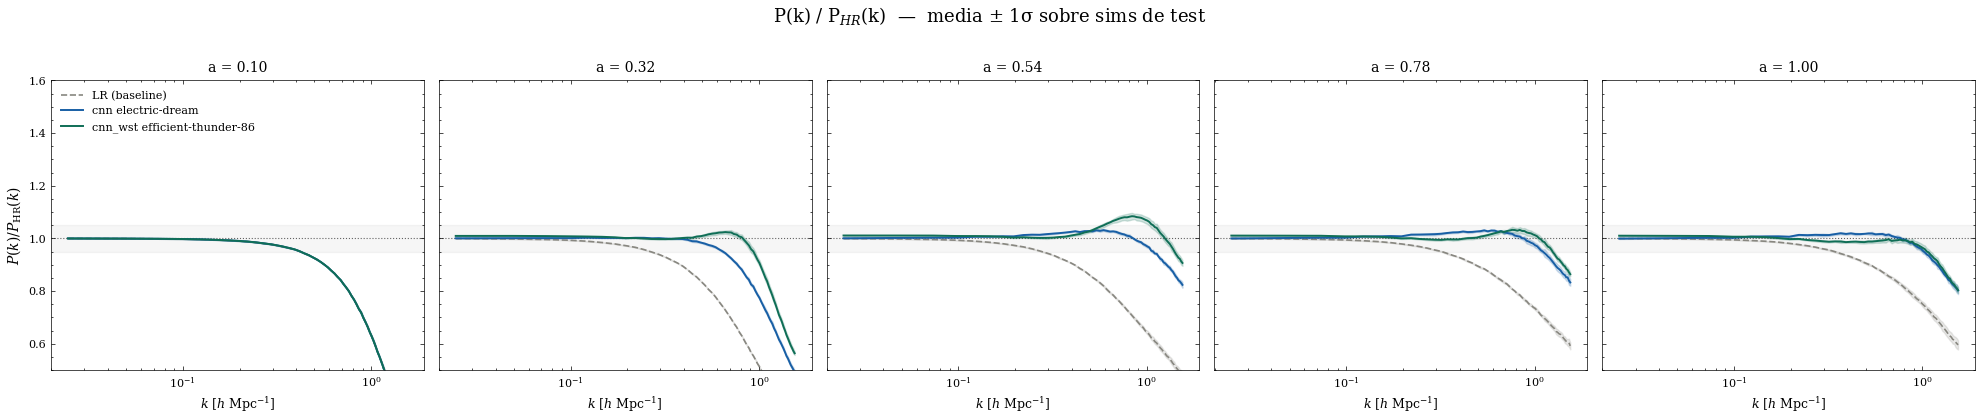

Guardado: pk_ratio_comparison_wst.pdf


In [ ]:
COLORS  = ["#888780", "#185FA5", "#0F6E56", "#993C1D", "#533AB7"]
LS_MAP  = {
    "LR (baseline)": ("--", 1.2),
    "kcorr"        : ("-",  1.6),
    "cnn"          : ("-",  1.6),
    "cnn+kcorr"    : ("-",  1.8),
}

run_names = list(results.keys())
n_snaps   = len(SNAP_EVAL)

fig, axes = plt.subplots(1, n_snaps, figsize=(4 * n_snaps, 4.2), sharey=True)
fig.suptitle("P(k) / P$_{HR}$(k)  —  media ± 1σ sobre sims de test",
             fontsize=13, y=1.01)

for col, snap_idx in enumerate(SNAP_EVAL):
    ax = axes[col]
    a_val = list(agg[run_names[0]].values())[col]["a"]
    ax.set_title(f"a = {a_val:.2f}", fontsize=10)
    ax.axhline(1.0, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.axhspan(0.95, 1.05, alpha=0.07, color="gray")   # banda ±5%

    for ci, run_name in enumerate(run_names):
        d   = agg[run_name][snap_idx]
        mu  = d["pk_ratio_mean"]
        sig = d["pk_ratio_std"]
        ls, lw = LS_MAP.get(run_name, ("-", 1.4))
        color   = COLORS[ci % len(COLORS)]

        ax.semilogx(k_bins, mu, ls=ls, lw=lw, color=color,
                    label=run_name if col == 0 else None)
        ax.fill_between(k_bins, mu - sig, mu + sig,
                        alpha=0.18, color=color)

    ax.set_xlabel(r"$k$ [$h$ Mpc$^{-1}$]", fontsize=9)
    ax.set_ylim(0.5, 1.6)
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.set_ylabel(r"$P(k)/P_{\rm HR}(k)$", fontsize=10)

axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("pk_ratio_comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Guardado: pk_ratio_comparison_wst.pdf")

## 7. Panel de comparación — cross-correlation r(k)


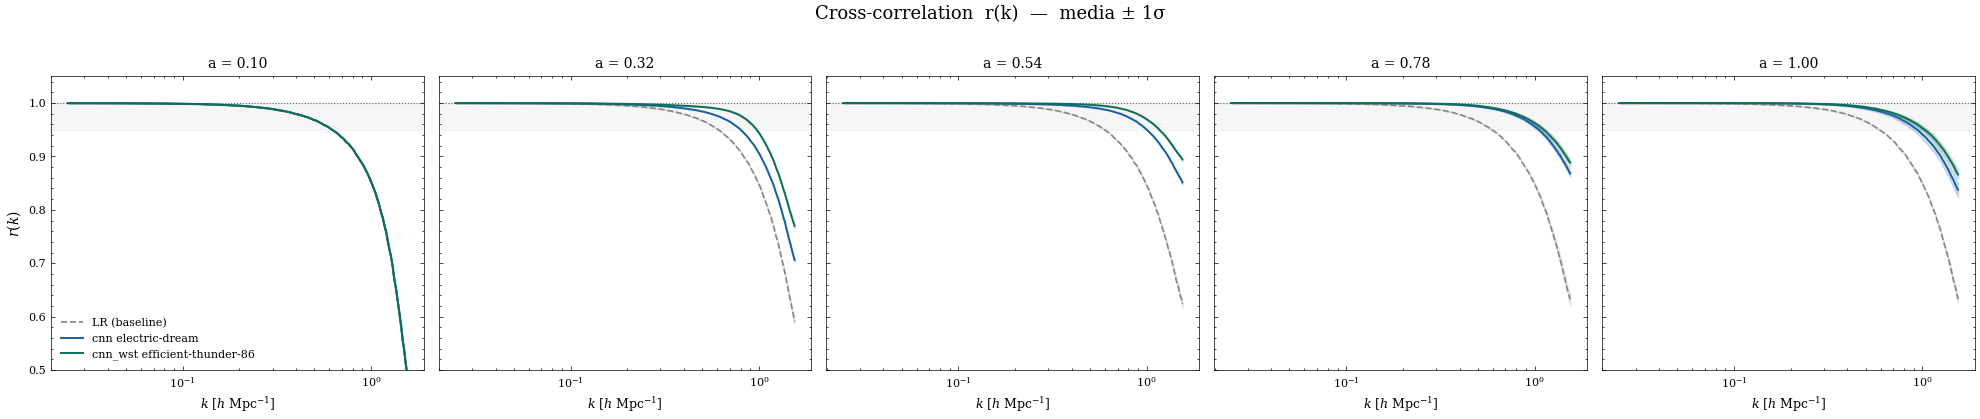

Guardado: cross_corr_comparison_wst.pdf


In [ ]:
fig, axes = plt.subplots(1, n_snaps, figsize=(4 * n_snaps, 4.2), sharey=True)
fig.suptitle("Cross-correlation  r(k)  —  media ± 1σ",
             fontsize=13, y=1.01)

for col, snap_idx in enumerate(SNAP_EVAL):
    ax = axes[col]
    a_val = list(agg[run_names[0]].values())[col]["a"]
    ax.set_title(f"a = {a_val:.2f}", fontsize=10)
    ax.axhline(1.0, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.axhspan(0.95, 1.0, alpha=0.07, color="gray")

    for ci, run_name in enumerate(run_names):
        d   = agg[run_name][snap_idx]
        mu  = d["cross_corr_mean"]
        sig = d["cross_corr_std"]
        ls, lw = LS_MAP.get(run_name, ("-", 1.4))
        color   = COLORS[ci % len(COLORS)]

        ax.semilogx(k_bins, mu, ls=ls, lw=lw, color=color,
                    label=run_name if col == 0 else None)
        ax.fill_between(k_bins, mu - sig, mu + sig,
                        alpha=0.18, color=color)

    ax.set_xlabel(r"$k$ [$h$ Mpc$^{-1}$]", fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.set_ylabel(r"$r(k)$", fontsize=10)

axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig("cross_corr_comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Guardado: cross_corr_comparison_wst.pdf")

## 8. Pos MSE vs scale factor


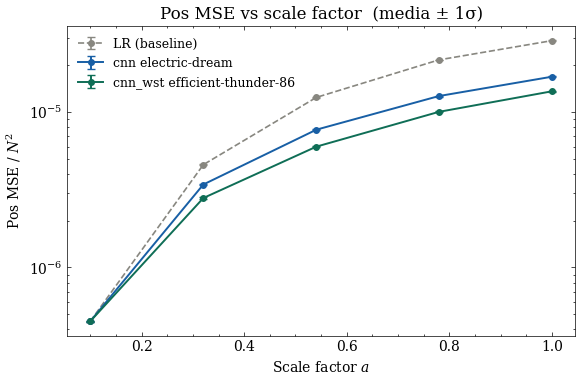

Guardado: pos_mse_vs_a_wst.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title("Pos MSE vs scale factor  (media ± 1σ)", fontsize=12)

for ci, run_name in enumerate(run_names):
    a_vals  = [agg[run_name][s]["a"]            for s in SNAP_EVAL]
    mu_vals = [agg[run_name][s]["pos_mse_mean"] for s in SNAP_EVAL]
    sd_vals = [agg[run_name][s]["pos_mse_std"]  for s in SNAP_EVAL]
    ls, lw  = LS_MAP.get(run_name, ("-", 1.4))
    color   = COLORS[ci % len(COLORS)]

    ax.errorbar(a_vals, mu_vals, yerr=sd_vals,
                fmt=f"{ls}o", lw=lw, ms=4,
                color=color, label=run_name, capsize=3)

ax.set_xlabel(r"Scale factor $a$", fontsize=10)
ax.set_ylabel(r"Pos MSE / $N^2$", fontsize=10)
ax.legend(fontsize=9)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("pos_mse_vs_a.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Guardado: pos_mse_vs_a_wst.pdf")

## 9. Proyecciones 2D de densidad


Construyendo modelo para cnn electric-dream...
Ejecutando ODE con corrección cnn para cnn electric-dream...
Construyendo modelo para cnn_wst efficient-thunder-86...
Ejecutando ODE con corrección cnn_wst para cnn_wst efficient-thunder-86...
Slab: z=[120, 136]  grosor=16 celdas  (6.2% de la caja)

Rangos por panel:
  LR (baseline)                   min=0.000  max=7.223  std=1.074
  cnn electric-dream              min=0.000  max=7.109  std=1.093
  cnn_wst efficient-thunder-86    min=0.000  max=7.259  std=1.108
  HR (target)                     min=0.000  max=7.597  std=1.140


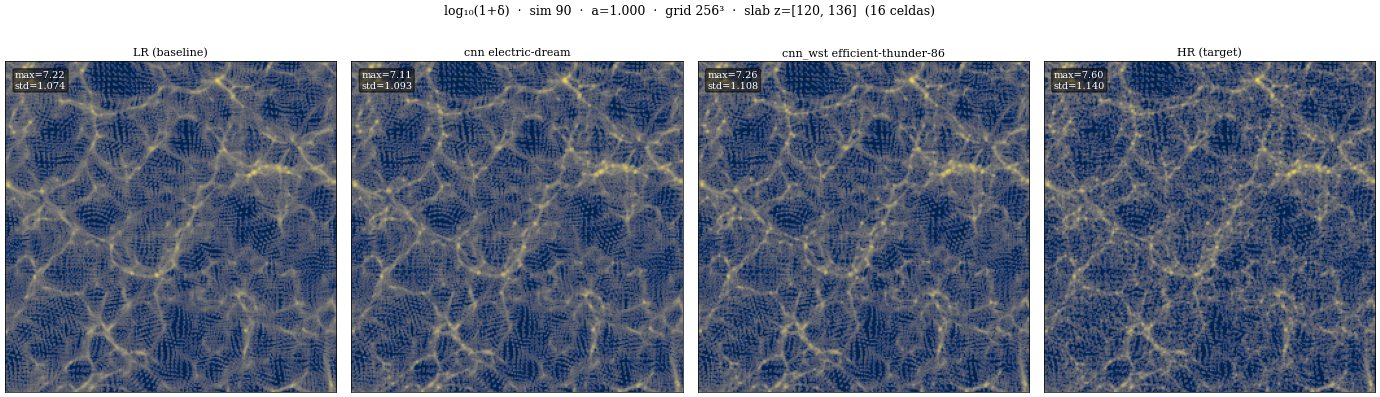

Guardado: density_hr_grid_wst.pdf


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Proyecciones de densidad 2D — comparación LR / modelos / HR
# ══════════════════════════════════════════════════════════════════════════════
#
# Pipeline completo:
#   1. Las posiciones están en mesh_lr units [0, 128) (convención de read_data.py)
#   2. Se escalan * (dst_mesh/src_mesh) → [0, 256) antes del CIC deposit
#      Esto llena el grid HR completo evitando celdas vacías
#   3. Se extrae un slab de grosor SLAB_THICKNESS celdas centrado en Z0_FRAC
#      de la caja (en unidades de dst_mesh)
#   4. Se suma la densidad a lo largo del eje z → proyección 2D
#   5. Se aplica log10(1 + delta) para comprimir el rango dinámico
#   6. Todos los paneles usan la misma escala de color basada en el HR
#
# Variables que controlan la visualización:
#   SLAB_THICKNESS : grosor del slab en celdas de dst_mesh (256³)
#                    valores típicos: 8 (delgado), 32 (medio), 64 (grueso)
#                    más grueso → más suave, menos grueso → más estructura
#   Z0_FRAC        : posición central del slab como fracción de la caja [0,1]
#                    0.5 = centro, 0.25 = cuarto inferior, etc.
# ══════════════════════════════════════════════════════════════════════════════

# ── Parámetros de visualización — modifica aquí ───────────────────────────────
SLAB_THICKNESS = 16     # grosor del slab en celdas de dst_mesh (256³)
Z0_FRAC        = 0.5    # fracción de la caja para el centro del slab [0, 1]
SIM_ID_VIZ = TEST_SIM_IDS[0]
SNAP_VIZ = SNAP_EVAL[-1] 
a_viz = list(agg[run_names[0]].values())[SNAP_EVAL.index(SNAP_VIZ)]["a"]
# ── Runs a comparar ───────────────────────────────────────────────────────────
RUNS_SHOW = {
    "LR (baseline)"        : None,
    # "kcorr royal-energy-58": list(RUNS.values())[5],
    "cnn electric-dream"   : list(RUNS.values())[1],
    "cnn_wst efficient-thunder-86" : list(RUNS.values())[2],
    "HR (target)"          : None,
}


def slab_projection_hr(pos_numpy_mesh_lr, src_mesh=MESH_LR, dst_mesh=MESH_HR,
                        slab_thickness=32, z0_frac=0.5):
    """
    Proyecta posiciones en una slab 2D depositando en dst_mesh.

    Parámetros
    ----------
    pos_numpy_mesh_lr : np.ndarray [N, 3]
        Posiciones en src_mesh units (e.g. [0, 128) para MESH_LR=128).
    src_mesh : int
        Resolución de la simulación de origen (128 para LR, 256 para HR).
    dst_mesh : int
        Resolución del grid de deposit para visualización (256 por defecto).
    slab_thickness : int
        Grosor del slab en celdas de dst_mesh.
        Controla cuánto volumen se integra en z.
        Valores pequeños (~8)  → más estructura, más ruidoso.
        Valores grandes (~64)  → más suave, menos contraste.
    z0_frac : float
        Posición central del slab como fracción de la caja [0, 1].
        0.5 = centro de la caja.

    Retorna
    -------
    proj : np.ndarray [dst_mesh, dst_mesh]
        Proyección log10(1 + delta) en la dirección z.
    """
    # Escala de src_mesh a dst_mesh (e.g. 128→256: scale=2.0)
    scale  = dst_mesh / src_mesh

    # Centro y semiancho del slab en unidades de dst_mesh
    z0     = int(z0_frac * dst_mesh)
    half_h = slab_thickness // 2

    # Escalar posiciones y wrappear periódicamente al grid dst_mesh
    # Esto distribuye las partículas uniformemente en [0, dst_mesh)
    pos_scaled = jnp.mod(
        jnp.array(pos_numpy_mesh_lr, dtype=jnp.float32) * scale,
        dst_mesh,
    )

    # CIC deposit → campo de densidad [dst_mesh, dst_mesh, dst_mesh]
    delta    = positions_to_delta(pos_scaled, dst_mesh)
    delta_np = np.asarray(jax.device_get(delta))
    del pos_scaled, delta

    # Extraer slab y sumar en z → proyección 2D [dst_mesh, dst_mesh]
    sl   = slice(max(z0 - half_h, 0), min(z0 + half_h, dst_mesh))
    proj = delta_np[:, :, sl].sum(axis=-1)

    # Comprimir rango dinámico con log10(1 + delta)
    # clip a 1e-4 evita log de cero en celdas vacías
    return np.log1p( proj)


# ── Calcular proyecciones ─────────────────────────────────────────────────────
pos_lr_v, vel_lr_v, pos_hr_v, vel_hr_v, avals_v = load_sim(SIM_ID_VIZ)

projs_show = {}
for run_name, pkl_path in RUNS_SHOW.items():

    if run_name == "HR (target)":
        # HR en mesh_lr units (read_data.py normaliza todo a mesh_lr)
        snap_cpu = np.asarray(jax.device_get(pos_hr_v[SNAP_VIZ]))

    elif run_name == "LR (baseline)":
        # LR directo de disco — sin integrador adicional
        snap_cpu = np.asarray(jax.device_get(pos_lr_v[SNAP_VIZ]))

    else:
        # Modelos: correr ODE completo con corrección neuronal
        corr     = infer_model_type(run_name)
        print(f"Construyendo modelo para {run_name}...")
        print(f"Ejecutando ODE con corrección {corr} para {run_name}...")
        params_v = load_params(pkl_path)
        if corr == "kcorr":
            model_v = build_kcorr_model()
        elif corr == "cnn_wst":
            model_v = build_wst_model()
        else:
            model_v = build_cnn_model()
        pos_eval, _ = run_ode_with_model(
            pos_lr_v[0], vel_lr_v[0], avals_v, model_v, params_v, corr
        )
        pos_eval_cpu = np.asarray(jax.device_get(pos_eval))
        snap_cpu     = pos_eval_cpu[-1]   # snapshot final a=1.0
        del pos_eval, pos_eval_cpu, params_v, model_v

    # Mismo pipeline para todos: escalar a dst_mesh y proyectar
    projs_show[run_name] = slab_projection_hr(
        snap_cpu,
        slab_thickness=SLAB_THICKNESS,
        z0_frac=Z0_FRAC,
    )
    del snap_cpu
    jax.effects_barrier()
    jax.clear_caches()

del pos_lr_v, vel_lr_v, pos_hr_v, vel_hr_v

# ── Escalas basadas en HR ─────────────────────────────────────────────────────
# Todos los paneles usan la misma escala → comparación directa con el target
# vmin_fair = projs_show["HR (target)"].min()
# vmax_fair = projs_show["HR (target)"].max()

vmin_fair = min(p.min() for p in projs_show.values())
vmax_fair = max(p.max() for p in projs_show.values())

z0_cells = int(Z0_FRAC * MESH_HR)
print(f"Slab: z=[{z0_cells - SLAB_THICKNESS//2}, {z0_cells + SLAB_THICKNESS//2}]"
      f"  grosor={SLAB_THICKNESS} celdas  ({SLAB_THICKNESS/MESH_HR*100:.1f}% de la caja)")
print("\nRangos por panel:")
for k, p in projs_show.items():
    print(f"  {k:30s}  min={p.min():.3f}  max={p.max():.3f}  std={p.std():.3f}")

# ── Figura ────────────────────────────────────────────────────────────────────
n_show = len(projs_show)
fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4.0))
fig.suptitle(
    f"log₁₀(1+δ)  ·  sim {SIM_ID_VIZ}  ·  a={a_viz:.3f}"
    f"  ·  grid {MESH_HR}³"
    f"  ·  slab z=[{z0_cells-SLAB_THICKNESS//2}, {z0_cells+SLAB_THICKNESS//2}]"
    f"  ({SLAB_THICKNESS} celdas)",
    fontsize=9, y=1.02,
)

for ax, (key, proj) in zip(axes, projs_show.items()):
    im = ax.imshow(proj, cmap="cividis",
                   vmin=vmin_fair, vmax=vmax_fair, origin="lower")
    ax.set_title(key, fontsize=8, pad=4)
    ax.text(0.03, 0.97, f"max={proj.max():.2f}\nstd={proj.std():.3f}",
            transform=ax.transAxes, fontsize=7, va="top", color="white",
            bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
    ax.set_xticks([]); ax.set_yticks([])


plt.tight_layout()
plt.savefig("density_hr_grid_wst.pdf", bbox_inches="tight", dpi=300)
plt.show()
print(f"Guardado: density_hr_grid_wst.pdf")

Slab: z=[120, 136]  grosor=16 celdas  (6.2% de la caja)

Rangos por panel:
  LR (baseline)                   min=0.000  max=7.223  std=1.074
  kcorr royal-energy-58           min=0.000  max=7.180  std=1.089
  cnn electric-dream              min=0.000  max=7.110  std=1.093
  HR (target)                     min=0.000  max=7.597  std=1.140


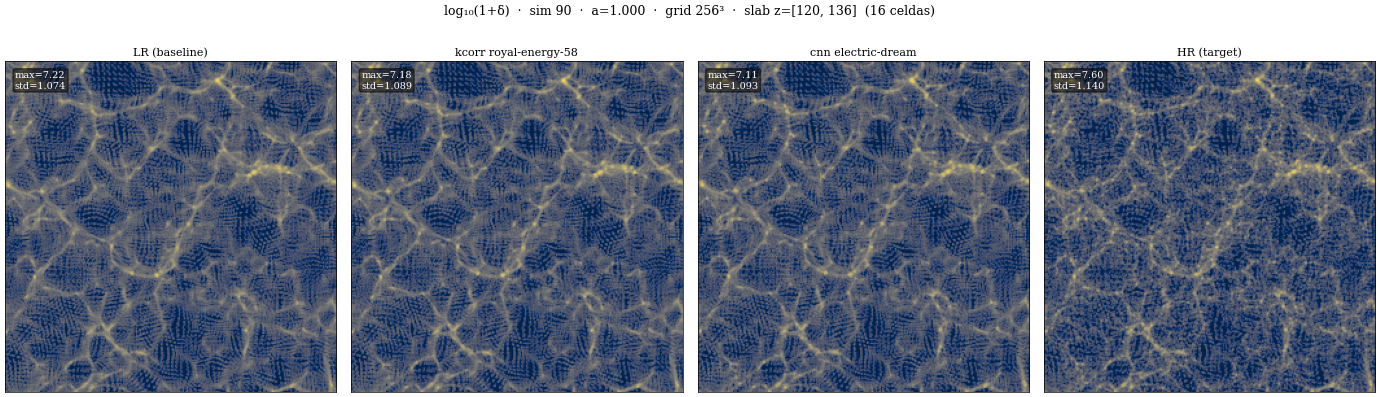

Guardado: density_hr_grid.pdf


In [ ]:
# ── Parámetros de visualización — modifica aquí ───────────────────────────────
SLAB_THICKNESS = 16     # grosor del slab en celdas de dst_mesh (256³)
Z0_FRAC        = 0.5    # fracción de la caja para el centro del slab [0, 1]

pos_lr_v, vel_lr_v, pos_hr_v, vel_hr_v, avals_v = load_sim(SIM_ID_VIZ)

projs_show = {}
for run_name, pkl_path in RUNS_SHOW.items():

    if run_name == "HR (target)":
        # HR en mesh_lr units (read_data.py normaliza todo a mesh_lr)
        snap_cpu = np.asarray(jax.device_get(pos_hr_v[SNAP_VIZ]))

    elif run_name == "LR (baseline)":
        # LR directo de disco — sin integrador adicional
        snap_cpu = np.asarray(jax.device_get(pos_lr_v[SNAP_VIZ]))

    else:
        # Modelos: correr ODE completo con corrección neuronal
        corr     = infer_model_type(run_name)
        params_v = load_params(pkl_path)
        if corr == "kcorr":
            model_v = build_kcorr_model()
        elif corr == "cnn_wst":
            model_v = build_wst_model()
        else:
            model_v = build_cnn_model()
        pos_eval, _ = run_ode_with_model(
            pos_lr_v[0], vel_lr_v[0], avals_v, model_v, params_v, corr
        )
        pos_eval_cpu = np.asarray(jax.device_get(pos_eval))
        snap_cpu     = pos_eval_cpu[-1]   # snapshot final a=1.0
        del pos_eval, pos_eval_cpu, params_v, model_v

    # Mismo pipeline para todos: escalar a dst_mesh y proyectar
    projs_show[run_name] = slab_projection_hr(
        snap_cpu,
        slab_thickness=SLAB_THICKNESS,
        z0_frac=Z0_FRAC,
    )
    del snap_cpu
    jax.effects_barrier()
    jax.clear_caches()

del pos_lr_v, vel_lr_v, pos_hr_v, vel_hr_v

# ── Escalas basadas en HR ─────────────────────────────────────────────────────
# Todos los paneles usan la misma escala → comparación directa con el target
# vmin_fair = projs_show["HR (target)"].min()
# vmax_fair = projs_show["HR (target)"].max()

vmin_fair = min(p.min() for p in projs_show.values())
vmax_fair = max(p.max() for p in projs_show.values())

z0_cells = int(Z0_FRAC * MESH_HR)
print(f"Slab: z=[{z0_cells - SLAB_THICKNESS//2}, {z0_cells + SLAB_THICKNESS//2}]"
      f"  grosor={SLAB_THICKNESS} celdas  ({SLAB_THICKNESS/MESH_HR*100:.1f}% de la caja)")
print("\nRangos por panel:")
for k, p in projs_show.items():
    print(f"  {k:30s}  min={p.min():.3f}  max={p.max():.3f}  std={p.std():.3f}")

# ── Figura ────────────────────────────────────────────────────────────────────
n_show = len(projs_show)
fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4.0))
fig.suptitle(
    f"log₁₀(1+δ)  ·  sim {SIM_ID_VIZ}  ·  a={a_viz:.3f}"
    f"  ·  grid {MESH_HR}³"
    f"  ·  slab z=[{z0_cells-SLAB_THICKNESS//2}, {z0_cells+SLAB_THICKNESS//2}]"
    f"  ({SLAB_THICKNESS} celdas)",
    fontsize=9, y=1.02,
)

for ax, (key, proj) in zip(axes, projs_show.items()):
    im = ax.imshow(proj, cmap="cividis",
                   vmin=vmin_fair, vmax=vmax_fair, origin="lower")
    ax.set_title(key, fontsize=8, pad=4)
    ax.text(0.03, 0.97, f"max={proj.max():.2f}\nstd={proj.std():.3f}",
            transform=ax.transAxes, fontsize=7, va="top", color="white",
            bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
    ax.set_xticks([]); ax.set_yticks([])


plt.tight_layout()
plt.savefig("density_hr_grid.pdf", bbox_inches="tight", dpi=300)
plt.show()
print(f"Guardado: density_hr_grid.pdf")

## 10. Guardar resultados agregados


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Save all numerical results to results_wst/
#
# Files:
#   metrics_per_sim_<ts>.csv      — one row per (run, sim, snapshot)
#                                    full P(k) and r(k) vectors as columns
#   metrics_aggregated_<ts>.csv   — mean±std aggregated over sims
#                                    key k-values as scalar columns
#   k_bins_<ts>.npy               — k-vector [n_bins] float64
#   eval_results_<ts>.json        — same as aggregated but nested JSON
# ════════════════════════════════════════════════════════════════════════════
import json

def _model_type_label(run_name):
    if run_name == "LR (baseline)": return "baseline"
    if "cnn_wst" in run_name:       return "cnn_wst"
    if "kcorr" in run_name and "cnn" not in run_name: return "kcorr"
    if "cnn+kcorr" in run_name:     return "cnn_kcorr"
    return "cnn"


# ── 1. Per-sim flat CSV ───────────────────────────────────────────────────────
rows_flat = []
for run_name, run_res in results.items():
    mtype = _model_type_label(run_name)
    for sim_id, sim_metrics in run_res.items():
        for i, snap_idx in enumerate(SNAP_EVAL):
            row = {
                "run"        : run_name,
                "model_type" : mtype,
                "sim_id"     : sim_id,
                "snap_idx"   : snap_idx,
                "a"          : sim_metrics["avals"][i],
                "pos_mse"    : sim_metrics["pos_mse"][i],
            }
            for ki, kval in enumerate(k_bins):
                row[f"pk_ratio_k{kval:.4f}"]   = float(sim_metrics["pk_ratio"][i][ki])
                row[f"cross_corr_k{kval:.4f}"] = float(sim_metrics["cross_corr"][i][ki])
            rows_flat.append(row)

df_flat = pd.DataFrame(rows_flat)
csv_flat = RESULTS_DIR / f"metrics_per_sim_{EVAL_TIMESTAMP}.csv"
df_flat.to_csv(csv_flat, index=False)
print(f"✓ Flat CSV     → {csv_flat}  ({len(df_flat)} rows)")


# ── 2. Aggregated summary CSV ─────────────────────────────────────────────────
rows_agg = []
K_REFS = [0.1, 0.2, 0.3, 0.5, 0.6, 0.8, 1.0, 1.5, 2.0]
for run_name in results:
    mtype = _model_type_label(run_name)
    for snap_idx in SNAP_EVAL:
        d = agg[run_name][snap_idx]
        row = {
            "run"          : run_name,
            "model_type"   : mtype,
            "snap_idx"     : snap_idx,
            "a"            : d["a"],
            "pos_mse_mean" : d["pos_mse_mean"],
            "pos_mse_std"  : d["pos_mse_std"],
        }
        for kref in K_REFS:
            ki = int(np.argmin(np.abs(k_bins - kref)))
            row[f"pk_ratio_mean_k{kref}"]   = float(d["pk_ratio_mean"][ki])
            row[f"pk_ratio_std_k{kref}"]    = float(d["pk_ratio_std"][ki])
            row[f"cross_corr_mean_k{kref}"] = float(d["cross_corr_mean"][ki])
            row[f"cross_corr_std_k{kref}"]  = float(d["cross_corr_std"][ki])
        rows_agg.append(row)

df_agg = pd.DataFrame(rows_agg)
csv_agg = RESULTS_DIR / f"metrics_aggregated_{EVAL_TIMESTAMP}.csv"
df_agg.to_csv(csv_agg, index=False)
print(f"✓ Aggregated   → {csv_agg}  ({len(df_agg)} rows)")


# ── 3. k-bins array ───────────────────────────────────────────────────────────
kbins_path = RESULTS_DIR / f"k_bins_{EVAL_TIMESTAMP}.npy"
np.save(kbins_path, k_bins)
print(f"✓ k_bins       → {kbins_path}")


# ── 4. JSON (backward compat) ─────────────────────────────────────────────────
export = {"k_bins": k_bins.tolist(), "snap_eval_indices": SNAP_EVAL, "runs": {}}
for run_name in results:
    export["runs"][run_name] = {}
    for snap_idx in SNAP_EVAL:
        d = agg[run_name][snap_idx]
        export["runs"][run_name][str(snap_idx)] = {
            "a"               : d["a"],
            "pk_ratio_mean"   : d["pk_ratio_mean"].tolist(),
            "pk_ratio_std"    : d["pk_ratio_std"].tolist(),
            "cross_corr_mean" : d["cross_corr_mean"].tolist(),
            "cross_corr_std"  : d["cross_corr_std"].tolist(),
            "pos_mse_mean"    : d["pos_mse_mean"],
            "pos_mse_std"     : d["pos_mse_std"],
        }
json_path = RESULTS_DIR / f"eval_results_{EVAL_TIMESTAMP}.json"
with open(json_path, "w") as f:
    json.dump(export, f, indent=2)
print(f"✓ JSON         → {json_path}")
print(f"\n✓ All metrics saved to {RESULTS_DIR.resolve()}")


✓ Flat CSV     → results_wst/metrics_per_sim_20260402_104844.csv  (75 rows)
✓ Aggregated   → results_wst/metrics_aggregated_20260402_104844.csv  (15 rows)
✓ k_bins       → results_wst/k_bins_20260402_104844.npy
✓ JSON         → results_wst/eval_results_20260402_104844.json

✓ All metrics saved to /cosmos_storage/home/diegovillalba/JaxPM/pm2nbody/notebooks/results_wst


## 11. Save density slab projections as .npy


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Save slab projections as .npy arrays for later visualization in Quarto.
#
# Scope: SNAP_EVAL snapshots × SIM_IDS_SLAB sims × all RUNS.
# Each file: float32 array of shape (MESH_HR, MESH_HR)
#
# Extend SIM_IDS_SLAB to save more sims, e.g. SIM_IDS_SLAB = TEST_SIM_IDS
# ════════════════════════════════════════════════════════════════════════════
from scipy.ndimage import zoom as scipy_zoom

SIM_IDS_SLAB    = [SIM_ID_VIZ]    # extend for more sims
SNAPS_SLAB      = SNAP_EVAL       # [0, 12, 24, 37, 49]
SLAB_THICKNESS_SAVE = 16
Z0_FRAC_SAVE        = 0.5


def _run_slug(name):
    return name.replace(" ","_").replace("(","").replace(")","").replace("/","-")


def slab_projection_save(pos_numpy, src_mesh=MESH_LR, dst_mesh=MESH_HR,
                          slab_thickness=16, z0_frac=0.5):
    """CIC deposit → log10(1+delta) slab → float32 array."""
    scale  = dst_mesh / src_mesh
    z0     = int(z0_frac * dst_mesh)
    half_h = slab_thickness // 2
    pos_s  = jnp.mod(jnp.array(pos_numpy, dtype=jnp.float32) * scale, dst_mesh)
    delta  = positions_to_delta(pos_s, dst_mesh)
    d_np   = np.asarray(jax.device_get(delta))
    del pos_s, delta
    sl     = slice(max(z0 - half_h, 0), min(z0 + half_h, dst_mesh))
    proj   = d_np[:, :, sl].sum(axis=-1)
    return np.log10(np.clip(1.0 + proj, 1e-4, None)).astype(np.float32)


slab_metadata = {}

for run_name, pkl_path in RUNS.items():
    slug = _run_slug(run_name)
    corr = infer_model_type(run_name)

    if pkl_path is not None:
        params_s = load_params(pkl_path)
        if corr == "kcorr":
            model_s = build_kcorr_model()
        elif corr == "cnn_wst":
            model_s = build_wst_model()
        else:
            model_s = build_cnn_model()
    else:
        params_s = None
        model_s  = None

    for sim_id in tqdm(SIM_IDS_SLAB, desc=f"slabs {slug}"):
        pos_lr_s, vel_lr_s, pos_hr_s, vel_hr_s, avals_s = load_sim(sim_id)

        # Run ODE once — extract only viz snaps
        if corr is None:
            pos_eval_s = np.asarray(jax.device_get(pos_lr_s))
        else:
            pos_raw, _ = run_ode_with_model(
                pos_lr_s[0], vel_lr_s[0], avals_s, model_s, params_s, corr
            )
            pos_eval_s = np.asarray(jax.device_get(pos_raw))
            del pos_raw

        pos_hr_cpu = np.asarray(jax.device_get(pos_hr_s))

        for snap_idx in SNAPS_SLAB:
            # Model slab
            slab = slab_projection_save(
                pos_eval_s[snap_idx],
                slab_thickness=SLAB_THICKNESS_SAVE,
                z0_frac=Z0_FRAC_SAVE,
            )
            fname = f"{slug}_sim{sim_id}_snap{snap_idx:02d}.npy"
            np.save(SLABS_DIR / fname, slab)
            slab_metadata[fname] = {
                "run"            : run_name,
                "model_type"     : _model_type_label(run_name),
                "sim_id"         : sim_id,
                "snap_idx"       : snap_idx,
                "a"              : float(avals_s[snap_idx]),
                "slab_thickness" : SLAB_THICKNESS_SAVE,
                "z0_frac"        : Z0_FRAC_SAVE,
                "shape"          : list(slab.shape),
                "vmin"           : float(slab.min()),
                "vmax"           : float(slab.max()),
                "std"            : float(slab.std()),
                "is_hr_target"   : False,
            }
            del slab

            # HR target slab (once per sim/snap)
            fname_hr = f"HR_target_sim{sim_id}_snap{snap_idx:02d}.npy"
            if not (SLABS_DIR / fname_hr).exists():
                slab_hr = slab_projection_save(
                    pos_hr_cpu[snap_idx],
                    src_mesh=MESH_LR,
                    slab_thickness=SLAB_THICKNESS_SAVE,
                    z0_frac=Z0_FRAC_SAVE,
                )
                np.save(SLABS_DIR / fname_hr, slab_hr)
                slab_metadata[fname_hr] = {
                    "run"            : "HR (target)",
                    "model_type"     : "hr_target",
                    "sim_id"         : sim_id,
                    "snap_idx"       : snap_idx,
                    "a"              : float(avals_s[snap_idx]),
                    "slab_thickness" : SLAB_THICKNESS_SAVE,
                    "z0_frac"        : Z0_FRAC_SAVE,
                    "shape"          : list(slab_hr.shape),
                    "vmin"           : float(slab_hr.min()),
                    "vmax"           : float(slab_hr.max()),
                    "std"            : float(slab_hr.std()),
                    "is_hr_target"   : True,
                }
                del slab_hr

        del pos_eval_s, pos_hr_cpu, pos_lr_s, vel_lr_s, vel_hr_s
        jax.effects_barrier()
        jax.clear_caches()

    if params_s is not None:
        del params_s, model_s
    jax.clear_caches()

# Save metadata index
with open(SLABS_DIR / "metadata.json", "w") as f:
    json.dump(slab_metadata, f, indent=2)

n_model = sum(1 for v in slab_metadata.values() if not v["is_hr_target"])
n_hr    = sum(1 for v in slab_metadata.values() if     v["is_hr_target"])
print(f"\n✓ Slabs saved → {SLABS_DIR.resolve()}")
print(f"  Model : {n_model}  ({len(RUNS)} runs × {len(SIM_IDS_SLAB)} sims × {len(SNAPS_SLAB)} snaps)")
print(f"  HR    : {n_hr}  ({len(SIM_IDS_SLAB)} sims × {len(SNAPS_SLAB)} snaps)")
print(f"  Index : {SLABS_DIR}/metadata.json  ({len(slab_metadata)} entries)")

# Final folder tree
print(f"\n{'='*50}")
print(f"Folder: {RESULTS_DIR.resolve()}")
print(f"{'='*50}")
for p in sorted(RESULTS_DIR.rglob("*")):
    rel  = p.relative_to(RESULTS_DIR)
    size = f"  {p.stat().st_size/1024:.1f} KB" if p.is_file() else ""
    print(f"  {rel}{size}")


slabs cnn_wst_pious-wildflower-89:   0%|          | 0/1 [00:05<?, ?it/s]


ValueError: 'CNN/~/rescale/scale' with retrieved shape (26,) does not match shape=[14] dtype=<class 'jax.numpy.float64'>